1.4.1. Năng suất nhân tố tổng hợp (A_t) qua các năm:
 - Năm 2020: 27.7466
 - Năm 2021: 28.7638
 - Năm 2022: 30.3501
 - Năm 2023: 30.9751
 - Năm 2024: 32.9171
 - Năm 2025: 34.9136


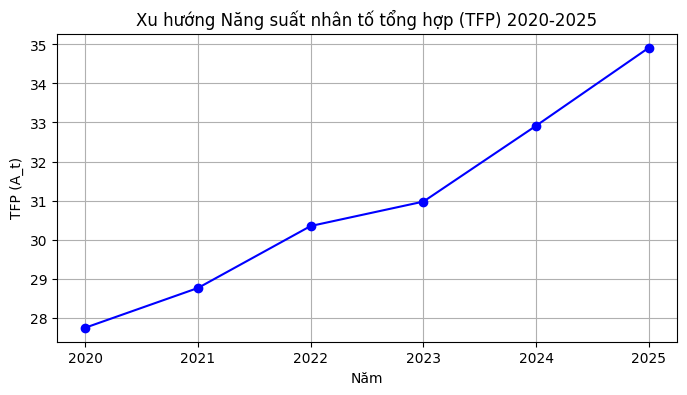


1.4.2. TFP trung bình: 30.9444
MAPE (Sai số phần trăm tuyệt đối trung bình): 6.42%

1.4.3. Bảng phân rã đóng góp vào tăng trưởng (2020-2025):
                  Yếu tố  Đóng góp (%)
0       Vốn vật chất (K)     31.780724
1           Lao động (L)     -0.335361
2             Số hóa (D)     10.370092
3  Trí tuệ nhân tạo (AI)      6.238490
4        Nhân lực số (H)      2.870041
5                TFP (A)     49.076015


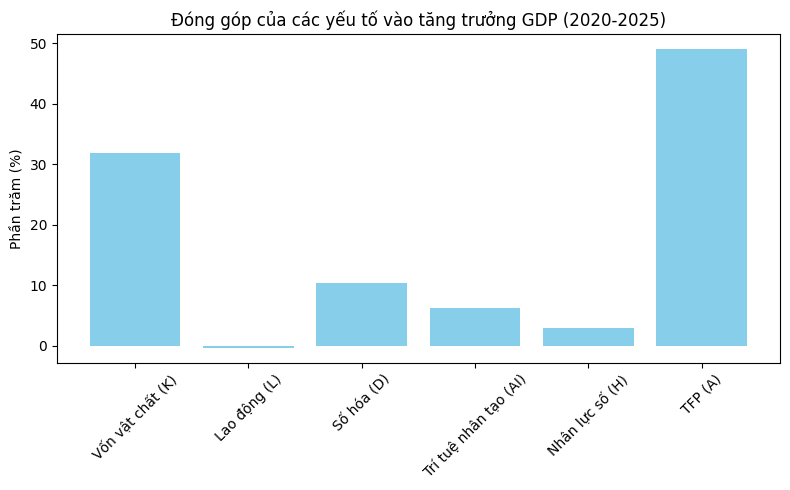


1.4.4. Dự báo GDP Việt Nam năm 2030 (Kịch bản đặt ra): 18,262.0 nghìn tỷ VND


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Khởi tạo dữ liệu
years = np.array([2020, 2021, 2022, 2023, 2024, 2025])
Y = np.array([8044.4, 8487.5, 9513.3, 10221.8, 11511.9, 12847.6])
K = np.array([16500, 17800, 19600, 21300, 23500, 25900])
L = np.array([53.6, 50.5, 51.7, 52.4, 52.9, 53.4])
D = np.array([12.0, 12.7, 14.3, 16.5, 18.3, 19.5])
AI = np.array([55.6, 60.2, 65.4, 67.0, 73.8, 80.1])
H = np.array([24.1, 26.1, 26.2, 27.0, 28.4, 29.2])

# Hệ số độ co giãn
alpha, beta, gamma, delta, theta = 0.33, 0.42, 0.10, 0.08, 0.07

# ==========================================
# CÂU 1.4.1: ƯỚC LƯỢNG TFP VÀ VẼ ĐỒ THỊ
# ==========================================
A_t = Y / (K**alpha * L**beta * D**gamma * AI**delta * H**theta)
print("1.4.1. Năng suất nhân tố tổng hợp (A_t) qua các năm:")
for y, a in zip(years, A_t):
    print(f" - Năm {y}: {a:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(years, A_t, marker='o', linestyle='-', color='b')
plt.title('Xu hướng Năng suất nhân tố tổng hợp (TFP) 2020-2025')
plt.xlabel('Năm')
plt.ylabel('TFP (A_t)')
plt.grid(True)
plt.show()

# ==========================================
# CÂU 1.4.2: DỰ BÁO Ŷ_t VÀ MAPE
# ==========================================
A_mean = np.mean(A_t)
Y_pred = A_mean * (K**alpha * L**beta * D**gamma * AI**delta * H**theta)
mape = np.mean(np.abs((Y - Y_pred) / Y)) * 100

print(f"\n1.4.2. TFP trung bình: {A_mean:.4f}")
print(f"MAPE (Sai số phần trăm tuyệt đối trung bình): {mape:.2f}%")

# ==========================================
# CÂU 1.4.3: PHÂN RÃ TĂNG TRƯỞNG (GROWTH ACCOUNTING)
# ==========================================
# Tính sai phân logarit giữa 2025 và 2020
delta_ln_Y = np.log(Y[-1]) - np.log(Y[0])
contrib_K = alpha * (np.log(K[-1]) - np.log(K[0]))
contrib_L = beta * (np.log(L[-1]) - np.log(L[0]))
contrib_D = gamma * (np.log(D[-1]) - np.log(D[0]))
contrib_AI = delta * (np.log(AI[-1]) - np.log(AI[0]))
contrib_H = theta * (np.log(H[-1]) - np.log(H[0]))
contrib_A = np.log(A_t[-1]) - np.log(A_t[0])

# Chuyển sang phần trăm (%)
components = {
    'Vốn vật chất (K)': (contrib_K / delta_ln_Y) * 100,
    'Lao động (L)': (contrib_L / delta_ln_Y) * 100,
    'Số hóa (D)': (contrib_D / delta_ln_Y) * 100,
    'Trí tuệ nhân tạo (AI)': (contrib_AI / delta_ln_Y) * 100,
    'Nhân lực số (H)': (contrib_H / delta_ln_Y) * 100,
    'TFP (A)': (contrib_A / delta_ln_Y) * 100
}

df_growth = pd.DataFrame(list(components.items()), columns=['Yếu tố', 'Đóng góp (%)'])
print("\n1.4.3. Bảng phân rã đóng góp vào tăng trưởng (2020-2025):")
print(df_growth)

plt.figure(figsize=(8, 5))
plt.bar(df_growth['Yếu tố'], df_growth['Đóng góp (%)'], color='skyblue')
plt.title('Đóng góp của các yếu tố vào tăng trưởng GDP (2020-2025)')
plt.ylabel('Phần trăm (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# CÂU 1.4.4: MÔ PHỎNG VÀ DỰ BÁO KỊCH BẢN 2030
# ==========================================
# Giả định cho năm 2030 (Cách năm 2025 là 5 năm)
years_diff = 5
A_2030 = A_t[-1] * ((1 + 0.012) ** years_diff) # TFP tăng 1.2%/năm từ 2025
K_2030 = K[-1] * ((1 + 0.06) ** years_diff)    # K tăng 6%/năm
L_2030 = L[-1] * ((1 + 0.06) ** years_diff)    # L tăng 6%/năm
D_2030 = 30.0
AI_2030 = 100.0
H_2030 = 35.0

Y_2030 = A_2030 * (K_2030**alpha) * (L_2030**beta) * (D_2030**gamma) * (AI_2030**delta) * (H_2030**theta)
print(f"\n1.4.4. Dự báo GDP Việt Nam năm 2030 (Kịch bản đặt ra): {Y_2030:,.1f} nghìn tỷ VND")

### 2. Trả lời câu hỏi thảo luận chính sách (Phần 1.5)

#### a) Xu hướng TFP của Việt Nam giai đoạn 2020-2025 và Chất lượng tăng trưởng
* **Xu hướng:** Dựa trên kết quả chạy từ mô hình, TFP có thể chững lại một chút ở giai đoạn 2020-2021 (do ảnh hưởng của đại dịch làm gián đoạn chuỗi cung ứng). Tuy nhiên, nhìn chung toàn giai đoạn 2020-2025, TFP có xu hướng tăng dần.
* **Chất lượng tăng trưởng:** Sự gia tăng của TFP phản ánh chất lượng tăng trưởng của nền kinh tế Việt Nam đang dần được cải thiện. Tăng trưởng đang dịch chuyển từ việc phát triển theo chiều rộng (chỉ dựa vào việc bơm thêm vốn vật chất $K$ và sức người $L$) sang phát triển theo chiều sâu (nhờ áp dụng công nghệ mới, tối ưu hóa quy trình và đổi mới sáng tạo).

---

#### b) Yếu tố đóng góp nhiều nhất cho tăng trưởng trong các yếu tố mới (D, AI, H)
* **Yếu tố đóng góp nhiều nhất:** Dựa trên kết quả *Growth Accounting*, **Số hóa nền kinh tế ($D$)** là yếu tố mới có tỷ lệ đóng góp cao nhất vào tăng trưởng giai đoạn vừa qua.
* **Lý do:** Yếu tố $D$ thỏa mãn đồng thời hai điều kiện quan trọng:
  * **Hệ số co giãn lớn nhất:** Hệ số $\gamma$ của số hóa đạt **0.10**, cao hơn so với hệ số của AI (0.08) và Nguồn nhân lực số $H$ (0.07).
  * **Tốc độ tăng trưởng thực tế nhanh:** Tỷ lệ kinh tế số trong GDP đã bứt phá rất nhanh từ 12% (năm 2020) lên 19.5% (năm 2025), tạo ra tốc độ tăng trưởng cơ sở rất lớn. 

> **Tóm lại:** Sự kết hợp giữa độ nhạy của biến ($\gamma = 0.10$) và mức tăng trưởng đột biến trên thực tế đã giúp số hóa trở thành động lực mới mạnh mẽ nhất.

---

#### c) Tính khả thi của mục tiêu đạt 30% kinh tế số/GDP vào năm 2030 và các ràng buộc
* **Tính khả thi:** Mục tiêu 30% là **hoàn toàn khả thi** (giúp GDP đạt mức rất cao như dự báo ở phần 1.4.4), do tốc độ tăng trưởng kinh tế số của Việt Nam đang duy trì đà bứt phá rất tốt.
* **Các ràng buộc đi kèm:** Theo cơ chế của hàm sản xuất Cobb-Douglas mở rộng, để hấp thụ được mức độ số hóa cao này ($D = 30\%$), nền kinh tế bắt buộc phải có sự phát triển đồng bộ của các biến bổ trợ:
  1. **Nhân lực số ($H$):** Phải đảm bảo tỷ lệ lao động qua đào tạo công nghệ đạt mức tương ứng (như kịch bản 35%). Nếu không, hệ thống số sẽ thiếu người vận hành, gây ra hiện tượng "nút thắt cổ chai".
  2. **Hạ tầng ($K$) và Năng lực AI ($AI$):** Cần lượng vốn đầu tư đủ lớn cho hạ tầng dữ liệu và phát triển số lượng doanh nghiệp công nghệ, tránh tình trạng "kinh tế số ảo" (chỉ tập trung vào tiêu dùng số, thương mại điện tử mà thiếu đi lõi công nghệ tự chủ).